# Analyse environmentale des ESB aux Etats-Unis

## Dépendances

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des données

In [2]:
RAW_FILE = "../data/ESB_adoption_dataset_v8_update_august_2024.xlsx" # I renamed the file so pay attention to modify this line.
SHEET    = "1. District-level data"

MISSING_LOGICAL = {"Not applicable"}                         
MISSING_DATA    = {"Missing value", "Blank cell", "TBD", "N/A", "NA", "", " "}                      

In [3]:
df = (pd.read_excel(RAW_FILE, sheet_name=SHEET)
        .replace(list(MISSING_LOGICAL), "logical_na")
        .replace(list(MISSING_DATA), np.nan))

In [4]:
df = df.loc[:, 
            ['0a. Has committed ESBs?',
            '1a. State',
            '1f. City',
            '1p. Locale broad type (name)',
            '2a. Total number of buses',
            '3a. Number of ESBs committed ',
            '3b. Number of delivered or operating ESBs',
            '3i. Percent of fleet that is electric',
            '3k. Utility/energy company involved 1',
            '3k. Utility/energy company involved 2',
            '3k. Utility/energy company involved 3',
            '5h. Ozone concentration',
            '5l. Average rate of asthma among adults aged 18 and older',
            '5o. EPA 2022 Clean School Bus Rebate Program prioritized school district?',
            '5p. EPA 2023 Clean School Bus Grant & Rebate Programs prioritized school district?',
            '6a. Has any expression of interest in ESBs?',
            '6f. Member of Climate Mayors Electric Vehicle Purchasing Collaborative?',
            '6g. School district sustainability commitment',
            '6h. District contains Generation180 Solar School?']
            ]

In [5]:
df.rename(columns={'1g. State': '1g. State Code'}, inplace=True)

## Traitement des noms de colonnes

In [6]:
df.columns = [col[4:] for col in df.columns]
print(df.columns)

Index(['Has committed ESBs?', 'State', 'City', 'Locale broad type (name)',
       'Total number of buses', 'Number of ESBs committed ',
       'Number of delivered or operating ESBs',
       'Percent of fleet that is electric',
       'Utility/energy company involved 1',
       'Utility/energy company involved 2',
       'Utility/energy company involved 3', 'Ozone concentration',
       'Average rate of asthma among adults aged 18 and older',
       'EPA 2022 Clean School Bus Rebate Program prioritized school district?',
       'EPA 2023 Clean School Bus Grant & Rebate Programs prioritized school district?',
       'Has any expression of interest in ESBs?',
       'Member of Climate Mayors Electric Vehicle Purchasing Collaborative?',
       'School district sustainability commitment',
       'District contains Generation180 Solar School?'],
      dtype='object')


In [7]:
# Strip leading and trailing whitespace
df.columns = df.columns.str.strip()
# Replace spaces with underscores and convert to lowercase
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [8]:
print(df.columns)

Index(['has_committed_esbs?', 'state', 'city', 'locale_broad_type_(name)',
       'total_number_of_buses', 'number_of_esbs_committed',
       'number_of_delivered_or_operating_esbs',
       'percent_of_fleet_that_is_electric',
       'utility/energy_company_involved_1',
       'utility/energy_company_involved_2',
       'utility/energy_company_involved_3', 'ozone_concentration',
       'average_rate_of_asthma_among_adults_aged_18_and_older',
       'epa_2022_clean_school_bus_rebate_program_prioritized_school_district?',
       'epa_2023_clean_school_bus_grant_&_rebate_programs_prioritized_school_district?',
       'has_any_expression_of_interest_in_esbs?',
       'member_of_climate_mayors_electric_vehicle_purchasing_collaborative?',
       'school_district_sustainability_commitment',
       'district_contains_generation180_solar_school?'],
      dtype='object')


## Gestions des valeurs manquantes

In [9]:
df.isna().sum()

has_committed_esbs?                                                                   0
state                                                                                 0
city                                                                                  8
locale_broad_type_(name)                                                              0
total_number_of_buses                                                              9786
number_of_esbs_committed                                                              0
number_of_delivered_or_operating_esbs                                                 0
percent_of_fleet_that_is_electric                                                   304
utility/energy_company_involved_1                                                 19379
utility/energy_company_involved_2                                                 19499
utility/energy_company_involved_3                                                 19513
ozone_concentration             

Nous pouvons voir que certaines variables ont beaucoup de valeurs manquantes. Ces variables ont une grande importance dans notre analyse, mais elles sont inutilisables car elles risquent de biaiser les résultats. Nous devons donc les supprimer.

In [10]:
df.drop(columns=['utility/energy_company_involved_1', 
               'utility/energy_company_involved_2', 
               'utility/energy_company_involved_3',
               'member_of_climate_mayors_electric_vehicle_purchasing_collaborative?',
               'school_district_sustainability_commitment',
               'district_contains_generation180_solar_school?'], inplace=True)

In [11]:
df.isna().sum()

has_committed_esbs?                                                                  0
state                                                                                0
city                                                                                 8
locale_broad_type_(name)                                                             0
total_number_of_buses                                                             9786
number_of_esbs_committed                                                             0
number_of_delivered_or_operating_esbs                                                0
percent_of_fleet_that_is_electric                                                  304
ozone_concentration                                                               6324
average_rate_of_asthma_among_adults_aged_18_and_older                             6450
epa_2022_clean_school_bus_rebate_program_prioritized_school_district?                0
epa_2023_clean_school_bus_grant_&_rebate_pr

## Matrice de corrélation

In [12]:
df_num = df.select_dtypes(include=[np.number])

In [13]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19516 entries, 0 to 19515
Data columns (total 7 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   total_number_of_buses                                  9730 non-null   float64
 1   number_of_esbs_committed                               19516 non-null  int64  
 2   number_of_delivered_or_operating_esbs                  19516 non-null  int64  
 3   percent_of_fleet_that_is_electric                      19212 non-null  float64
 4   ozone_concentration                                    13192 non-null  float64
 5   average_rate_of_asthma_among_adults_aged_18_and_older  13066 non-null  float64
 6   has_any_expression_of_interest_in_esbs?                19493 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

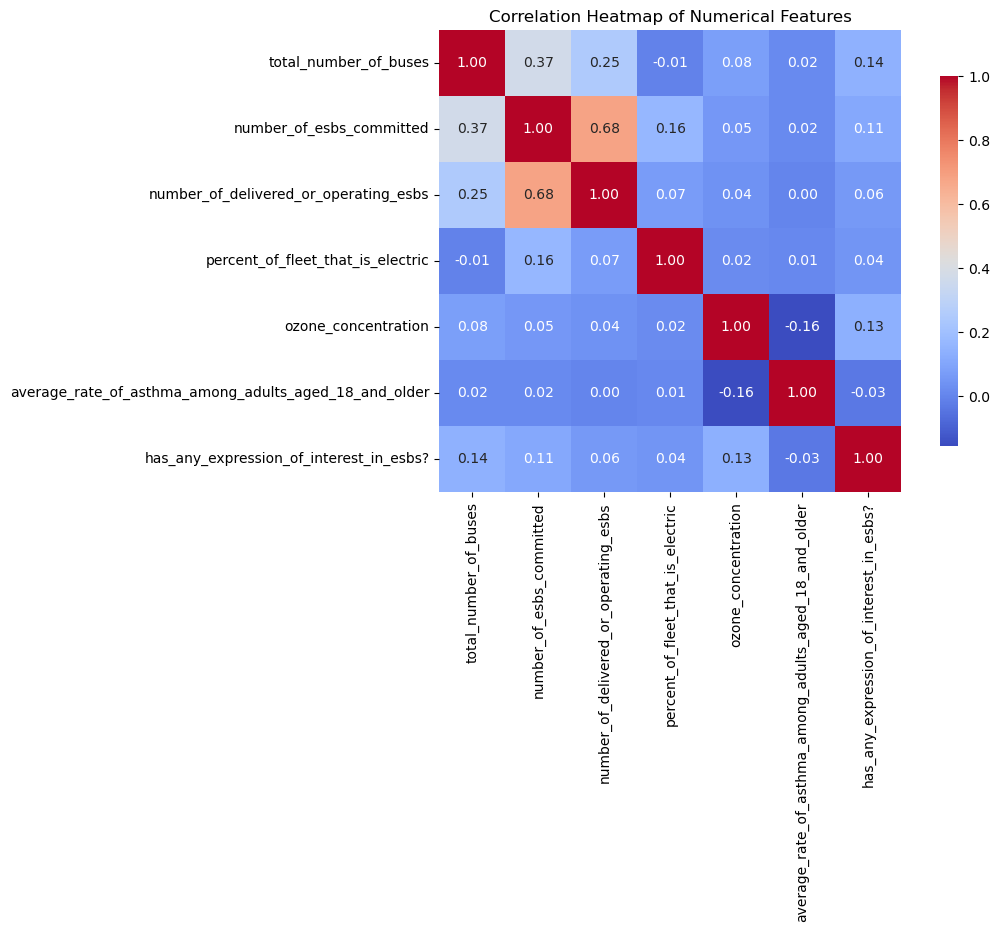

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Numerical Features')

On peut voir grâce à la matrice de corrélation que les variables 'number_of_esb_committed' et 'number_of_delivered_or_operating_esbs' sont très corrélées. Cela est logique car le nombre d'ESB livrés ou en fonctionnement est une partie du nombre total d'ESB engagés. Nous allons donc supprimer la variable 'number_of_esb_committed'.

In [15]:
df.drop(columns=['number_of_esbs_committed'], inplace=True)

df_num = df.select_dtypes(include=[np.number])

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

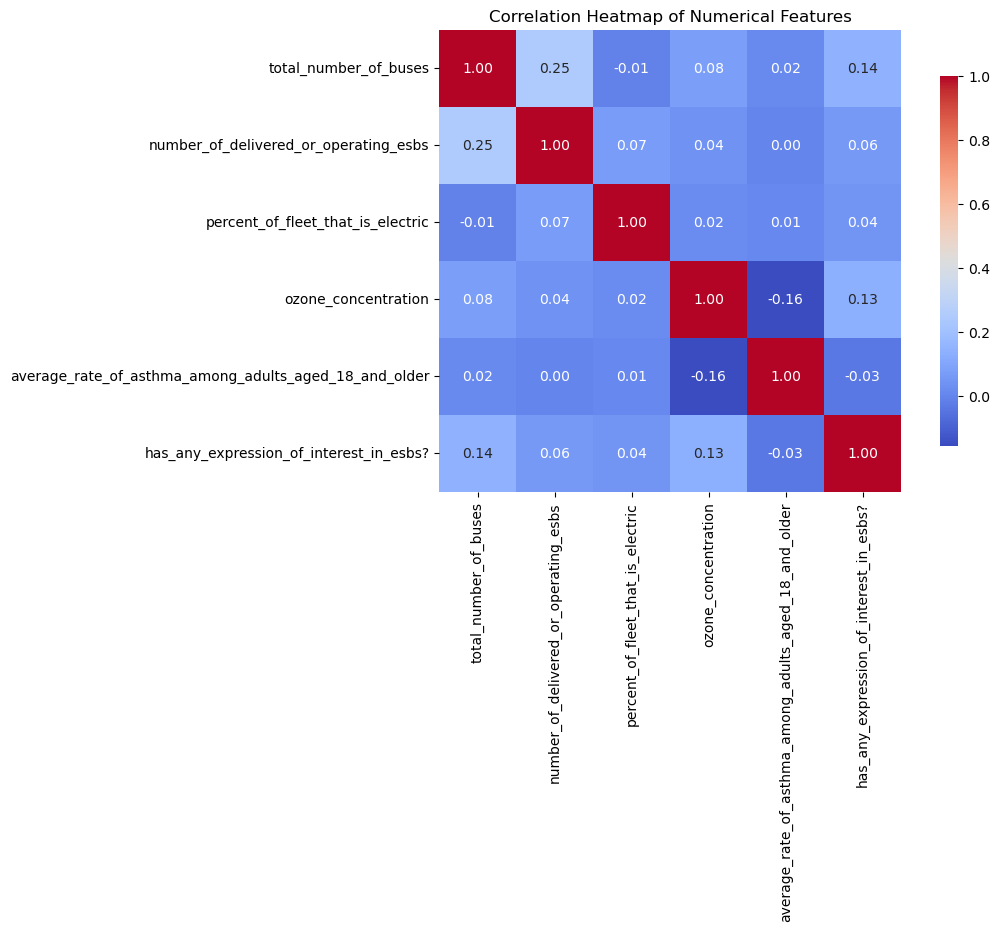

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Numerical Features')

In [22]:
X = df_num
X_features = X.columns

## Standardisation des variables

Puisque dans les algorithmes / modèles de clustering, la distance a un rôle important, on standardise les variables pour que des variables n'aient pas plus d'influence que d'autres lors du calcul des distances.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
df_scaled = pd.DataFrame(X_scaled, columns=X_features)
df_scaled.head()

,total_number_of_buses,number_of_delivered_or_operating_esbs,percent_of_fleet_that_is_electric,ozone_concentration,average_rate_of_asthma_among_adults_aged_18_and_older,has_any_expression_of_interest_in_esbs?
0,NaN,-0.069975,-0.07576,NaN,NaN,-0.678343
1,0.525036,-0.069975,-0.07576,0.238671,0.306364,-0.678343
2,1.077490,-0.069975,-0.07576,1.147963,-0.272058,-0.678343
3,0.503512,-0.069975,-0.07576,0.167279,-0.094132,-0.678343
4,NaN,-0.069975,-0.07576,NaN,NaN,-0.678343


Le but est de voir si certains états ont des caractéristiques environnementales similaires. Pour cela, il nous faut la colonne 'state' qui contient le nom des états. Nous allons donc l'ajouter à notre dataframe.

In [28]:
df_scaled['state'] = df['state']

In [29]:
df_scaled.head()

,total_number_of_buses,number_of_delivered_or_operating_esbs,percent_of_fleet_that_is_electric,ozone_concentration,average_rate_of_asthma_among_adults_aged_18_and_older,has_any_expression_of_interest_in_esbs?,state
0,NaN,-0.069975,-0.07576,NaN,NaN,-0.678343,ALABAMA
1,0.525036,-0.069975,-0.07576,0.238671,0.306364,-0.678343,ALABAMA
2,1.077490,-0.069975,-0.07576,1.147963,-0.272058,-0.678343,ALABAMA
3,0.503512,-0.069975,-0.07576,0.167279,-0.094132,-0.678343,ALABAMA
4,NaN,-0.069975,-0.07576,NaN,NaN,-0.678343,ALABAMA
